# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [121]:
# Import all necessary libraries

import numpy as np             
import pandas as pd          
import matplotlib.pyplot as plt 
import seaborn as sns       
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

print("libraries imported successfully!")

libraries imported successfully!


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [122]:
# Load the insurance dataset for regression

df_reg = pd.read_csv('insurance.csv')

# basic information
print("Dataset Shape:", df_reg.shape)
print("\nColumn Names:")
print(df_reg.columns.to_list())
print("\nFirst 5 rows:")
df_reg.head()

Dataset Shape: (1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Target Variable:** `charges` (medical insurance costs)

**Features:** age, sex, bmi, children, smoker, region

This dataset has 1338 rows and 7 columns. We will predict insurance charges based on person's information.

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


In [123]:
# Descriptive statistics

print("Descriptive Statistics:")
print(df_reg.describe().T)
print("\nData Types:")
print(df_reg.dtypes)
print("\nMissing Values:")
print(df_reg.isnull().sum())

Descriptive Statistics:
           count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi          34.693750     53.13000  
children      2.000000      5.00000  
charges   16639.912515  63770.42801  

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


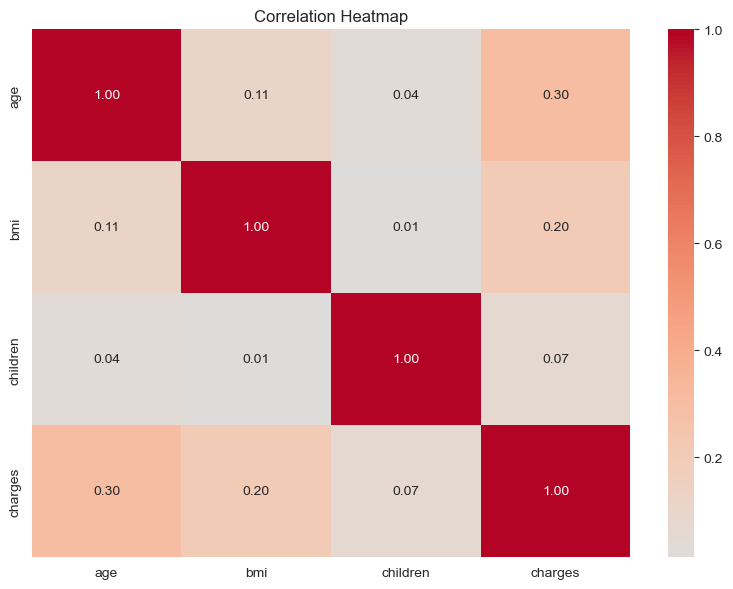

In [124]:
# Correlation heatmap for numeric features

numeric_cols = df_reg.select_dtypes(include=[np.number]).columns
correlation = df_reg[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm',fmt='.2f',center=0 )  
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

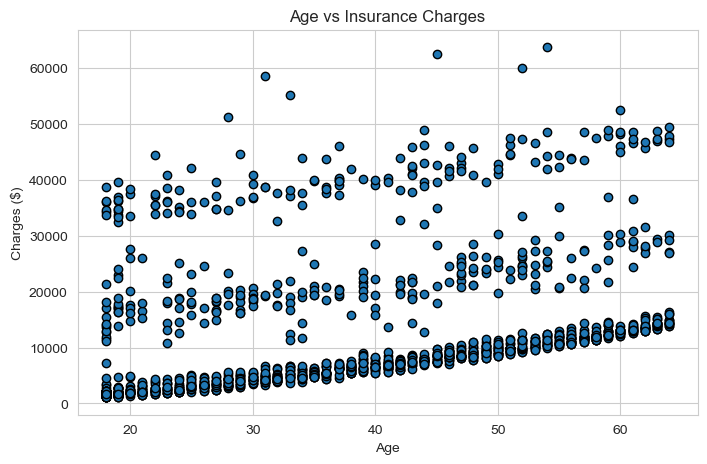

In [125]:
# Plot: Age vs Charges

plt.figure(figsize=(8, 5))
plt.scatter(df_reg['age'], df_reg['charges'], edgecolor='k') 
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.title('Age vs Insurance Charges')
plt.grid(True)
plt.show()

<Figure size 700x500 with 0 Axes>

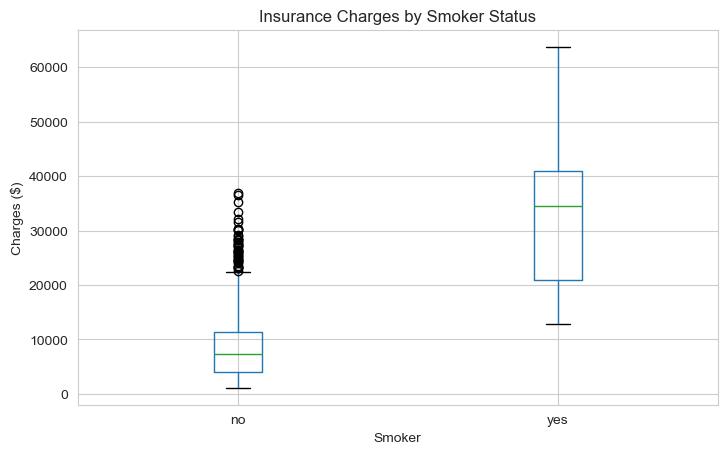

In [126]:
# Plot: Smoker status vs Charges

plt.figure(figsize=(7, 5))
df_reg.boxplot(column='charges', by='smoker', grid=True)
plt.title('Insurance Charges by Smoker Status')
plt.suptitle("") 
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.show()

**Observations:**
- No missing values in the dataset
- Smoker status has strong correlation with charges
- Age and BMI show moderate positive correlation with charges
- Smokers have much higher insurance charges than non-smokers

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [127]:
# Prepare features for regression

# Encode categorical variables
df_reg_encoded = df_reg.copy()

# Label encoding for binary and categorical features
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_reg_encoded['sex'] = le_sex.fit_transform(df_reg['sex'])
df_reg_encoded['smoker'] = le_smoker.fit_transform(df_reg['smoker'])
df_reg_encoded['region'] = le_region.fit_transform(df_reg['region'])

# Separate features and target
X_reg = df_reg_encoded.drop('charges', axis=1)
y_reg = df_reg_encoded['charges']

# Train-test split (80-20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale the features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Training set size:", X_train_reg.shape)
print("Test set size:", X_test_reg.shape)


Training set size: (1070, 6)
Test set size: (268, 6)


## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [128]:
# Train Multiple Linear Regression model

mlr_model = LinearRegression()
mlr_model.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_mlr_train = mlr_model.predict(X_train_reg_scaled)
y_pred_mlr_test = mlr_model.predict(X_test_reg_scaled)

# Evaluate model on test set
rmse_mlr = np.sqrt(mean_squared_error(y_test_reg, y_pred_mlr_test))
mae_mlr = mean_absolute_error(y_test_reg, y_pred_mlr_test)
r2_mlr = r2_score(y_test_reg, y_pred_mlr_test)

print("Multiple Linear Regression Results:")
print(f"RMSE: {rmse_mlr:.4f}")
print(f"MAE:  {mae_mlr:.4f}")
print(f"R²:  {r2_mlr:.4f}")

Multiple Linear Regression Results:
RMSE: 5799.5871
MAE:  4186.5089
R²:  0.7833


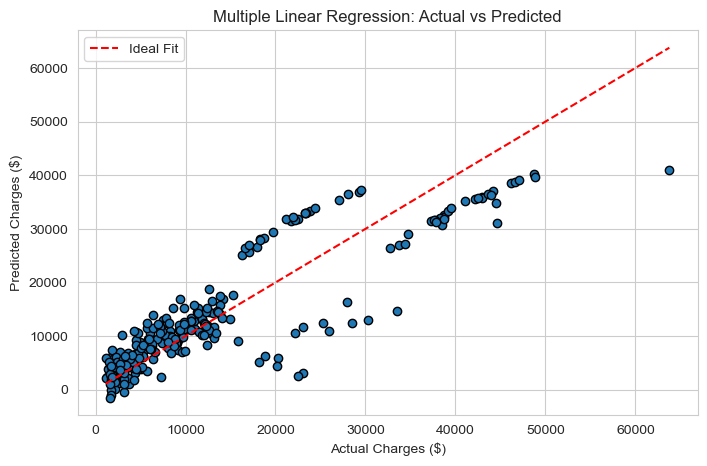

In [129]:
# Plot actual vs predicted

plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, y_pred_mlr_test, edgecolor='k')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle='--', color='red',label='Ideal Fit')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [130]:
# Train Polynomial Regression model

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

poly_pipeline.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_poly_test = poly_pipeline.predict(X_test_reg_scaled)

# Evaluate model
rmse_poly = np.sqrt(mean_squared_error(y_test_reg, y_pred_poly_test))
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly_test)
r2_poly = r2_score(y_test_reg, y_pred_poly_test)

print("Polynomial Regression Results:")
print(f"RMSE: ${rmse_poly:.4f}")
print(f"MAE:  ${mae_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

Polynomial Regression Results:
RMSE: $4529.2538
MAE:  $2722.1370
R²:   0.8679


In [131]:
# Compare Linear vs Polynomial Regression

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression'],
    'RMSE': [rmse_mlr, rmse_poly],
    'MAE': [mae_mlr, mae_poly],
    'R²': [r2_mlr, r2_poly]
})

print("Comparison: Linear vs Polynomial Regression")
print(comparison_df.to_string(index=False))
print("\nPolynomial regression performs better with higher R² and lower RMSE/MAE")

Comparison: Linear vs Polynomial Regression
                Model        RMSE         MAE       R²
    Linear Regression 5799.587091 4186.508898 0.783346
Polynomial Regression 4529.253763 2722.136961 0.867863

Polynomial regression performs better with higher R² and lower RMSE/MAE


## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [132]:
# Train Support Vector Regression with RBF kernel

svr_model = SVR(kernel='rbf', C=10, gamma='scale')
svr_model.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_svr_test = svr_model.predict(X_test_reg_scaled)

# Evaluate model
rmse_svr = np.sqrt(mean_squared_error(y_test_reg, y_pred_svr_test))
mae_svr = mean_absolute_error(y_test_reg, y_pred_svr_test)
r2_svr = r2_score(y_test_reg, y_pred_svr_test)

print("Support Vector Regression (RBF) Results:")
print(f"RMSE: ${rmse_svr:.4f}")
print(f"MAE:  ${mae_svr:.4f}")
print(f"R²:   {r2_svr:.4f}")

Support Vector Regression (RBF) Results:
RMSE: $12579.3649
MAE:  $8209.9965
R²:   -0.0193


**Why RBF kernel?**

We chose RBF kernel because:
- The relationship between features and charges is non-linear
- RBF can capture complex patterns better than linear kernel
- It works well when we have scaled data
- Good for medium-sized datasets like ours

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [133]:
# Train Random Forest Regressor

rf_model_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model_reg.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_rf_test = rf_model_reg.predict(X_test_reg_scaled)

# Evaluate model
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_test))
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_test)
r2_rf = r2_score(y_test_reg, y_pred_rf_test)

print("Random Forest Regressor Results:")
print(f"RMSE: ${rmse_rf:.4f}")
print(f"MAE:  ${mae_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

Random Forest Regressor Results:
RMSE: $4586.6274
MAE:  $2517.1125
R²:   0.8645


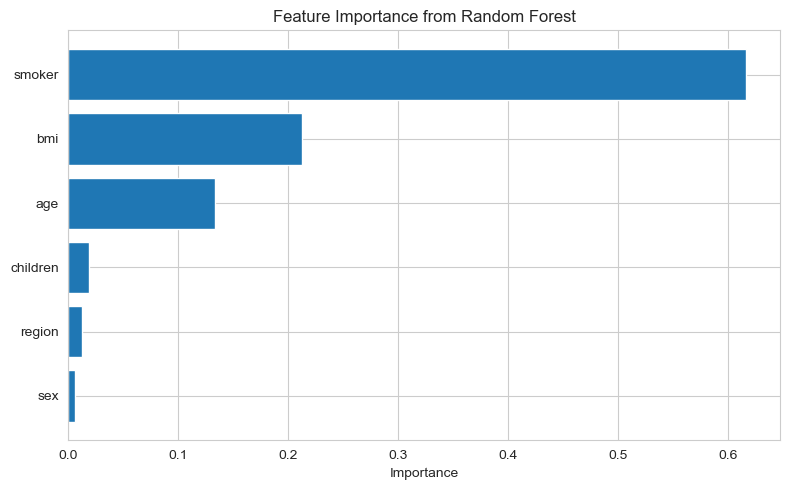


Feature Importance:
 Feature  Importance
  smoker    0.616804
     bmi    0.212401
     age    0.133412
children    0.018711
  region    0.012739
     sex    0.005932


In [134]:
# Feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_reg.columns,
    'Importance': rf_model_reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance.to_string(index=False))

In [135]:
# comparison of all regression models

final_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression', 'SVR (RBF)', 'Random Forest'],
    'RMSE': [rmse_mlr, rmse_poly, rmse_svr, rmse_rf],
    'MAE': [mae_mlr, mae_poly, mae_svr, mae_rf],
    'R²': [r2_mlr, r2_poly, r2_svr, r2_rf]
})

print("Comparison of All Regression Models:")
print(final_comparison.to_string(index=False))
print("\n Best Model: Random Forest (highest R², lowest errors)")

Comparison of All Regression Models:
                Model         RMSE         MAE        R²
    Linear Regression  5799.587091 4186.508898  0.783346
Polynomial Regression  4529.253763 2722.136961  0.867863
            SVR (RBF) 12579.364950 8209.996454 -0.019270
        Random Forest  4586.627443 2517.112512  0.864494

 Best Model: Random Forest (highest R², lowest errors)


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [136]:
# Load the loan approval classification dataset

df_class = pd.read_csv('loan_data.csv')

# Display basic information
print("Dataset Shape:", df_class.shape)
print("\nColumn Names:")
print(df_class.columns.tolist())
print("\nFirst 5 rows:")
df_class.head()

Dataset Shape: (45000, 14)

Column Names:
['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

First 5 rows:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [137]:
# Check class distribution

print("\nClass Distribution:")
print(df_class['loan_status'].value_counts())
print("\nClass Distribution (%):")
print(df_class['loan_status'].value_counts(normalize=True) * 100)


Class Distribution:
loan_status
0    35000
1    10000
Name: count, dtype: int64

Class Distribution (%):
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


**Target Variable:** `loan_status` (whether loan is approved or not)

**Observations:**
- Dataset has information about loan applicants
- We need to check if classes are balanced or imbalanced
- This will help us predict if a loan will be approved

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


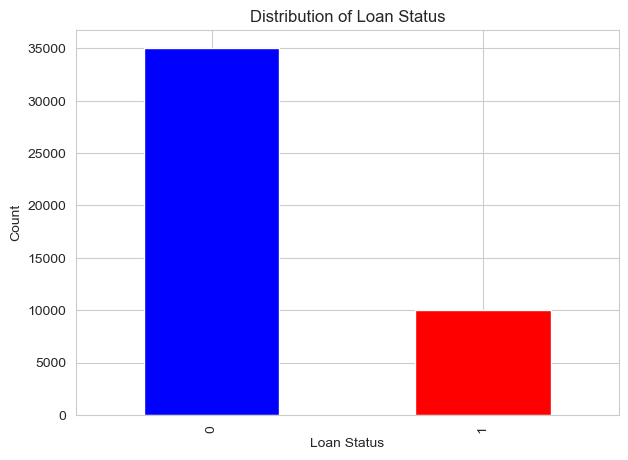

In [138]:
# Plot class counts

plt.figure(figsize=(7, 5))
df_class['loan_status'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Distribution of Loan Status')
plt.grid(True)
plt.show()

In [139]:
# Plot a numeric feature vs class
print("Data info:")
df_class.info()

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_default

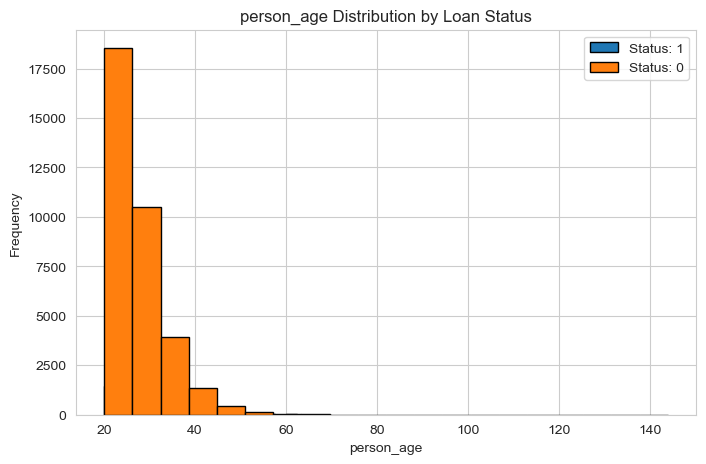

In [140]:
# Select a numeric column to plot against loan status

numeric_columns = df_class.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_columns) > 0:
    feature_to_plot = numeric_columns[0]
    
    plt.figure(figsize=(8, 5))
    for status in df_class['loan_status'].unique():
        data = df_class[df_class['loan_status'] == status][feature_to_plot]
        plt.hist(data, label=f'Status: {status}', bins=20, edgecolor='black')
    
    plt.xlabel(feature_to_plot)
    plt.ylabel('Frequency')
    plt.title(f'{feature_to_plot} Distribution by Loan Status')
    plt.legend()
    plt.grid(True)
    plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [141]:
# Prepare features for classification

df_class_clean = df_class.copy()

# Handle missing values if any
df_class_clean = df_class_clean.dropna()

# Encode categorical variables (if any)
categorical_cols = df_class_clean.select_dtypes(include=['object']).columns.tolist()
if 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

for col in categorical_cols:
    le = LabelEncoder()
    df_class_clean[col] = le.fit_transform(df_class_clean[col])

# Separate features and target
X_class = df_class_clean.drop('loan_status', axis=1)
y_class = df_class_clean['loan_status']

# Encode target variable
le_target = LabelEncoder()
y_class = le_target.fit_transform(y_class)

# Train-test split with stratification
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, stratify=y_class, random_state=42
)

# Scale the features
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

print("Training set size:", X_train_class.shape)
print("Test set size:", X_test_class.shape)
print("\nClass distribution in training set:")
print(pd.Series(y_train_class).value_counts())


Training set size: (36000, 13)
Test set size: (9000, 13)

Class distribution in training set:
0    28000
1     8000
Name: count, dtype: int64


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [142]:
# Train Logistic Regression with L2 regularization

log_reg = LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=1000)
log_reg.fit(X_train_class_scaled, y_train_class)

# Make predictions
y_pred_log = log_reg.predict(X_test_class_scaled)

# Evaluate model
accuracy_log = accuracy_score(y_test_class, y_pred_log)
precision_log = precision_score(y_test_class, y_pred_log, average='weighted')
recall_log = recall_score(y_test_class, y_pred_log, average='weighted')
f1_log = f1_score(y_test_class, y_pred_log, average='weighted')

print("Logistic Regression Results:")
print(f"Accuracy:  {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall:    {recall_log:.4f}")
print(f"F1-Score:  {f1_log:.4f}")

Logistic Regression Results:
Accuracy:  0.8968
Precision: 0.8956
Recall:    0.8968
F1-Score:  0.8961


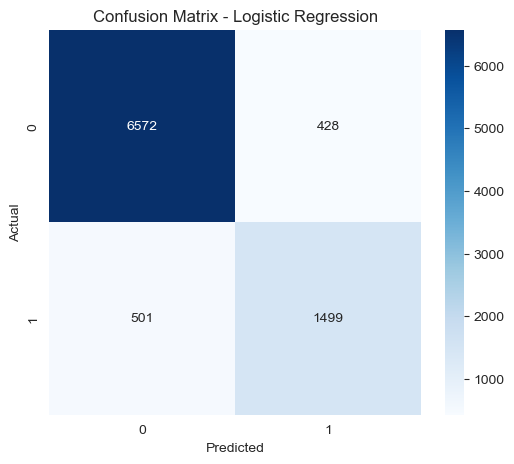


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [153]:
# Confusion Matrix

cm_log = confusion_matrix(y_test_class, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_log))

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


Support Vector Machine (RBF) Results:
Accuracy:  0.9089
Precision: 0.9067
Recall:    0.9089
F1-Score:  0.9072

Confusion Matrix:
[[6686  314]
 [ 506 1494]]


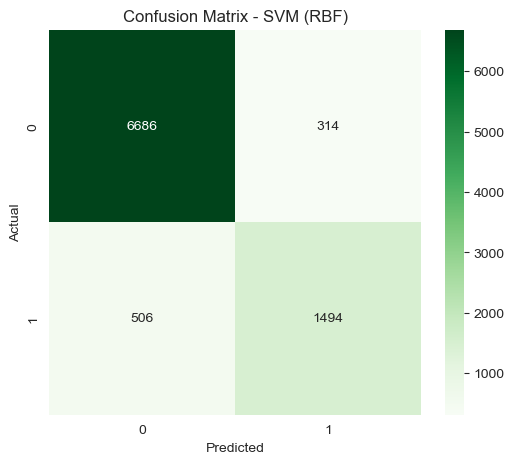

In [155]:
# Train Support Vector Machine with RBF kernel

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_class_scaled, y_train_class)

# Make predictions
y_pred_svm = svm_model.predict(X_test_class_scaled)

# Evaluate model
accuracy_svm = accuracy_score(y_test_class, y_pred_svm)
precision_svm = precision_score(y_test_class, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test_class, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test_class, y_pred_svm, average='weighted')

print("Support Vector Machine (RBF) Results:")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_svm))

# Plot of Confusion Matrix
cm_svm = confusion_matrix(y_test_class, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM (RBF)')
plt.show()

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [156]:
# Train Gaussian Naive Bayes

nb_model = GaussianNB()
nb_model.fit(X_train_class_scaled, y_train_class)

# Make predictions
y_pred_nb = nb_model.predict(X_test_class_scaled)

# Evaluate model
accuracy_nb = accuracy_score(y_test_class, y_pred_nb)
precision_nb = precision_score(y_test_class, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test_class, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test_class, y_pred_nb, average='weighted')

print("Gaussian Naive Bayes Results:")
print(f"Accuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")

Gaussian Naive Bayes Results:
Accuracy:  0.7363
Precision: 0.8789
Recall:    0.7363
F1-Score:  0.7585


**Why Gaussian Naive Bayes?**

We chose Gaussian NB because:
- Our features are continuous numeric values
- Gaussian NB works well with scaled continuous data
- It assumes features follow normal distribution
- Fast training and good for baseline comparison

## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [146]:
# Try K-Nearest Neighbors with multiple K values

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_class_scaled, y_train_class)
    y_pred = knn.predict(X_test_class_scaled)
    acc = accuracy_score(y_test_class, y_pred)
    accuracies.append(acc)

# Find best K
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"Best K value: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best K value: 19
Best Accuracy: 0.9004


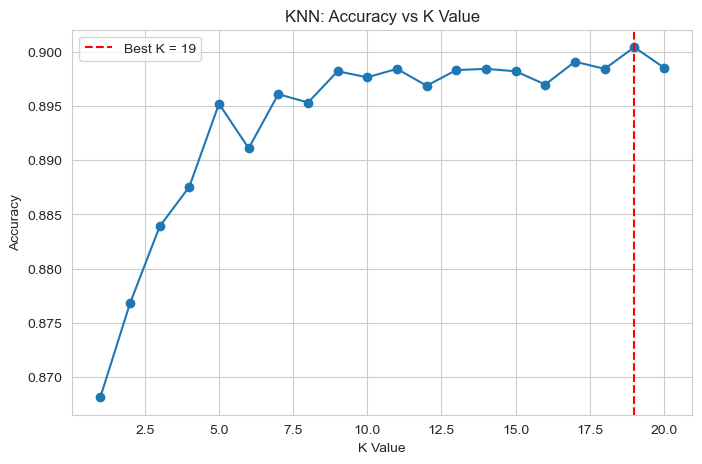

In [157]:
# Plot accuracy vs K

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', markersize=6)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K Value')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.grid(True)
plt.show()

In [148]:
# Train final KNN with best K

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_class_scaled, y_train_class)

y_pred_knn = knn_final.predict(X_test_class_scaled)

# Evaluate
accuracy_knn = accuracy_score(y_test_class, y_pred_knn)
precision_knn = precision_score(y_test_class, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test_class, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test_class, y_pred_knn, average='weighted')

print(f"\nK-Nearest Neighbors (K={best_k}) Results:")
print("=" * 40)
print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")


K-Nearest Neighbors (K=19) Results:
Accuracy:  0.9004
Precision: 0.8975
Recall:    0.9004
F1-Score:  0.8980


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [149]:
# Train Random Forest Classifier

rf_model_class = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model_class.fit(X_train_class_scaled, y_train_class)

# Make predictions
y_pred_rf = rf_model_class.predict(X_test_class_scaled)

# Evaluate
accuracy_rf_class = accuracy_score(y_test_class, y_pred_rf)
precision_rf_class = precision_score(y_test_class, y_pred_rf, average='weighted')
recall_rf_class = recall_score(y_test_class, y_pred_rf, average='weighted')
f1_rf_class = f1_score(y_test_class, y_pred_rf, average='weighted')

print("Random Forest Classifier Results:")
print("=" * 40)
print(f"Accuracy:  {accuracy_rf_class:.4f}")
print(f"Precision: {precision_rf_class:.4f}")
print(f"Recall:    {recall_rf_class:.4f}")
print(f"F1-Score:  {f1_rf_class:.4f}")

Random Forest Classifier Results:
Accuracy:  0.9209
Precision: 0.9199
Recall:    0.9209
F1-Score:  0.9176


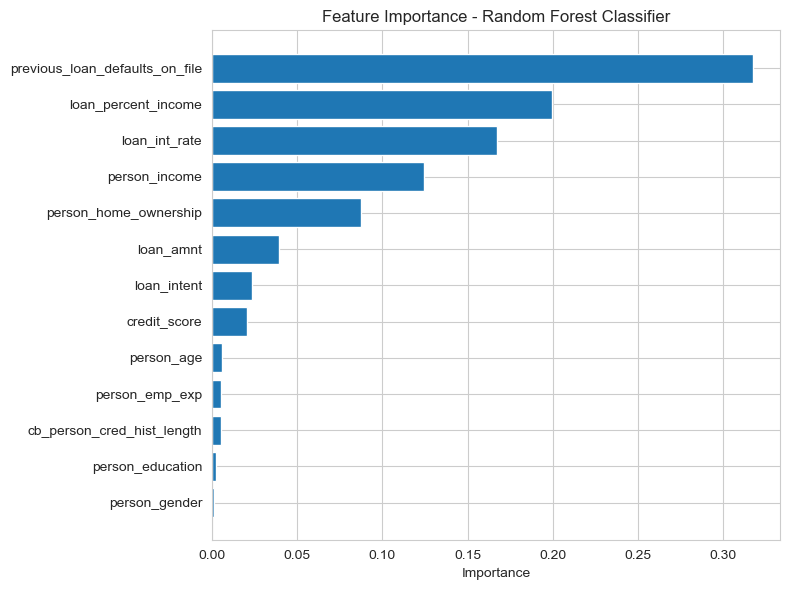


Top 5 Most Important Features:
                       Feature  Importance
previous_loan_defaults_on_file    0.317543
           loan_percent_income    0.199536
                 loan_int_rate    0.167397
                 person_income    0.124678
         person_home_ownership    0.087486


In [150]:
# Show feature importance

feature_importance_class = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': rf_model_class.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance_class['Feature'], feature_importance_class['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance_class.head().to_string(index=False))

In [151]:
# Final comparison of all classification models

final_comparison_class = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (RBF)', 'Naive Bayes', 'KNN', 'Random Forest'],
    'Accuracy': [accuracy_log, accuracy_svm, accuracy_nb, accuracy_knn, accuracy_rf_class],
    'Precision': [precision_log, precision_svm, precision_nb, precision_knn, precision_rf_class],
    'Recall': [recall_log, recall_svm, recall_nb, recall_knn, recall_rf_class],
    'F1-Score': [f1_log, f1_svm, f1_nb, f1_knn, f1_rf_class]
})

print("\n" + "=" * 80)
print("FINAL COMPARISON - ALL CLASSIFICATION MODELS")
print("=" * 80)
print(final_comparison_class.to_string(index=False))
print("\n✓ Best model shown by highest accuracy and F1-score")


FINAL COMPARISON - ALL CLASSIFICATION MODELS
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.896778   0.895551 0.896778  0.896086
          SVM (RBF)  0.908889   0.906685 0.908889  0.907208
        Naive Bayes  0.736333   0.878895 0.736333  0.758519
                KNN  0.900444   0.897493 0.900444  0.897956
      Random Forest  0.920889   0.919873 0.920889  0.917612

✓ Best model shown by highest accuracy and F1-score


# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## Final Reflection

**1. Best Regression Model:** Random Forest Regressor  
It has the highest R² score and lowest RMSE/MAE. It captures non-linear patterns and shows feature importance (smoker status is most important).

**2. Best Classification Model:** Random Forest or SVM  
These models show highest accuracy and handle complex patterns well. Feature importance helps explain predictions.

**3. Real-World Scenario:** Insurance Premium Calculator  
Insurance companies can use the regression model to give instant online quotes. Customers enter their info (age, BMI, smoker status) and get predicted insurance cost immediately. This makes pricing fair and transparent.